# DE Tech Adoption Radar (W2M5)

채용 공고의 기술어휘 빈도를 집계해, 국내 부트캠프 커리큘럼 기획에 필요한 두 가지를 본다.

1. 어떤 직무를 타겟으로 열까 -> 분기별 기술 수요 추이 (2025-Q4 → 2026-Q1 → 2026-Q2)
2. 그 직무에서 뭘 가르칠까 —> 직무별 기술 스택

- 파이프라인
    1. Extract(채용 공고 스크래핑)
    2. Transform(직무 분류,기술 용어 매칭, 분기 버킷)
    3. Load(SQLite)
    4. 워드클라우드 렌더 
    5. 데이터는 국내(KR) 28개사 + 미국(US) 35개사

In [17]:
%matplotlib inline
import pandas as pd

from scrape_signals import extract
from analyze import run as etl_run, crawl_summary
from render import (
    load_mentions, load_granular, pick_momentum_quarters,
    category_techstack, view_quarterly, view_by_category,
    view_crawl_volume, view_mindshare, view_us_vs_kr, view_momentum,
    view_competitor_bar, view_granular_bar, view_stack_profile,
)

## 1. Extract — 채용 공고 스크래핑

1. Greenhouse 임베드 보드
2. 그리팅 SSR
3. 개별 채용페이지
- 결과: `data/raw/*.json`
    - 이미 있으면 재사용
    - extract(force=True) 설정하면 재수집

In [18]:
tokens = extract()          # 캐시에 없는 회사만 스크래핑
print("수집 성공 회사 수:", len(tokens))

2026-07-09-09-45-00, [START-Extract] 채용 공고 웹 스크래핑 시작. 대상 63개사 (force=False)
2026-07-09-09-45-00, [CACHE-Extract] Coupang[KR]: 캐시 사용 (641건)
2026-07-09-09-45-00, [CACHE-Extract] Danggeun[KR]: 캐시 사용 (39건)
2026-07-09-09-45-00, [CACHE-Extract] Moloco[KR]: 캐시 사용 (47건)
2026-07-09-09-45-00, [CACHE-Extract] Sendbird[KR]: 캐시 사용 (18건)
2026-07-09-09-45-00, [CACHE-Extract] Krafton[KR]: 캐시 사용 (65건)
2026-07-09-09-45-00, [CACHE-Extract] Olive Young[KR]: 캐시 사용 (196건)
2026-07-09-09-45-00, [CACHE-Extract] Musinsa[KR]: 캐시 사용 (159건)
2026-07-09-09-45-00, [CACHE-Extract] Kurly[KR]: 캐시 사용 (67건)
2026-07-09-09-45-00, [CACHE-Extract] Team Sparta[KR]: 캐시 사용 (26건)
2026-07-09-09-45-00, [CACHE-Extract] Idus[KR]: 캐시 사용 (24건)
2026-07-09-09-45-00, [CACHE-Extract] 111Percent[KR]: 캐시 사용 (23건)
2026-07-09-09-45-00, [CACHE-Extract] MyRealTrip[KR]: 캐시 사용 (20건)
2026-07-09-09-45-00, [CACHE-Extract] Wadiz[KR]: 캐시 사용 (16건)
2026-07-09-09-45-00, [CACHE-Extract] W Concept[KR]: 캐시 사용 (13건)
2026-07-09-09-45-00, [CACHE-Extract] Gravit

## 2. Transform + Load 

- 제목으로 직무 분류
- 본문에서 기술 용어 매칭
- 분기별로 나눠서 jobs/mentions/granular_mentions 테이블에 나눠 적재

In [19]:
jobs_df, mentions_df, granular_df = etl_run()
print("jobs=%d | 기술직=%d | mentions=%d | granular=%d\n"
      % (len(jobs_df), int(jobs_df.is_tech_role.sum()), len(mentions_df), len(granular_df)))

print("[직무별 기술언급 분포]")
display(mentions_df.groupby(["category", "country"]).size().unstack(fill_value=0))

print("\n[분기 × 국가 기술언급 분포]")
q3 = mentions_df[mentions_df.quarter.isin(["2025-Q4", "2026-Q1", "2026-Q2"])]
display(q3.groupby(["quarter", "country"]).size().unstack(fill_value=0))

2026-07-09-09-45-00, [START-Transform] 직무 필터 + 기술어휘/세분제품 매칭 시작
2026-07-09-09-45-02, [END-Transform] 직무 4406건(기술직 947건) → 기술언급 2349건 · 세분제품 256건 추출
2026-07-09-09-45-02, [START-Load] SQLite 적재 시작 → radar.db
2026-07-09-09-45-02, [END-Load] 적재 완료. jobs=4406, mentions=2349, granular=256
jobs=4406 | 기술직=947 | mentions=2349 | granular=256

[직무별 기술언급 분포]


country,KR,US
category,,
DevOps/인프라/SRE,54,141
ML/AI 엔지니어링,70,243
기타 기술직,88,725
데이터 분석/사이언스,48,145
데이터 엔지니어링,102,320
모바일,0,2
백엔드,216,177
프론트엔드,16,2



[분기 × 국가 기술언급 분포]


country,KR,US
quarter,,
2025-Q4,74,113
2026-Q1,63,379
2026-Q2,343,983


## 2-1. 국가별 수집 규모 확인

,회사수,원본공고,기술직공고,기술언급,세분제품언급
country,,,,,
KR,28,1612,301,594,85
US,35,2794,646,1755,171
합계,63,4406,947,2349,256


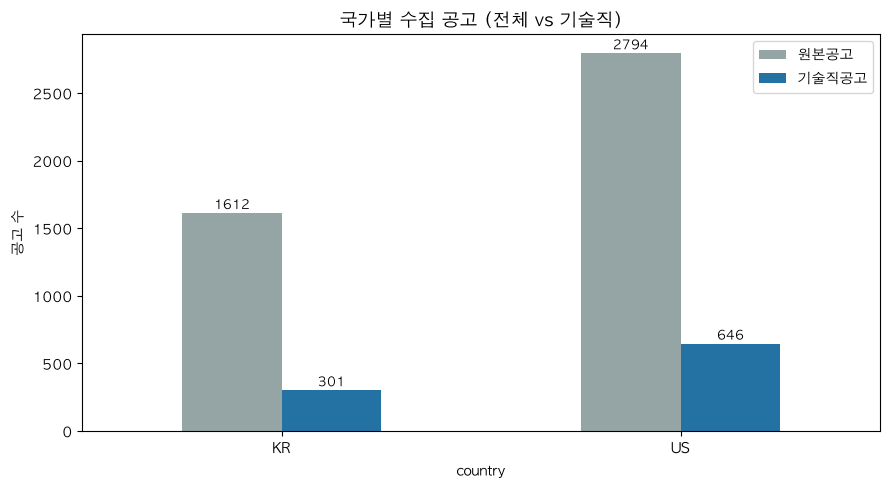

In [20]:
summary = crawl_summary()
display(summary)
fig, _ = view_crawl_volume(summary)

---
# 산출물 A — 직무별 기술 스택

직무별로 채용 공고에서 가장 많이 요구되는 기술 스택. 트랙별 커리큘럼 후보 목록이 된다. 기본 언어(Python/SQL/Java 등)도 포함한다.

In [21]:
m = load_mentions()
stack = category_techstack(m, top=12)
rows = []
for cat, techs in stack.items():
    top = ", ".join("%s(%d)" % (t, n) for t, n in techs.items())
    rows.append({"직무": cat, "기술언급수": sum(techs.values()), "상위 기술 스택(빈도)": top})
stack_table = pd.DataFrame(rows)
display(stack_table)

,직무,기술언급수,상위 기술 스택(빈도)
0,기타 기술직,636,"Python(124), AWS(100), Kubernetes(62), Postgre..."
1,데이터 엔지니어링,301,"Python(44), SQL(42), Airflow(40), Snowflake(28..."
2,백엔드,340,"AWS(56), Java(51), Kubernetes(46), Python(37),..."
3,ML/AI 엔지니어링,221,"Python(45), PyTorch(26), Spark(21), SQL(21), T..."
4,DevOps/인프라/SRE,185,"AWS(40), Kubernetes(32), GCP(24), Python(21), ..."
5,데이터 분석/사이언스,190,"SQL(64), Python(60), Snowflake(15), BigQuery(1..."
6,프론트엔드,18,"AWS(6), Docker(3), Kubernetes(1), MySQL(1), Re..."
7,모바일,2,"SQL(1), Python(1)"


### Cusotm Weight

1. 최신 분기(recency)
2. 회사당 1회 집계
3. 전체 대비 점유율

In [22]:
m = load_mentions()
w_stack = category_techstack(m, top=12, weighted=True)
rows = []
for cat, techs in w_stack.items():
    top = ", ".join("%s(%.1f)" % (t, float(s)) for t, s in techs.items())
    rows.append({"직무": cat, "상위 차별 기술 (가중점수)": top})
display(pd.DataFrame(rows))

,직무,상위 차별 기술 (가중점수)
0,기타 기술직,"Kubernetes(13.9), Terraform(13.7), Java(13.3),..."
1,데이터 엔지니어링,"Flink(21.6), Redshift(19.2), Airflow(18.8), Da..."
2,백엔드,"Redis(15.3), Java(14.1), MySQL(11.7), AWS(11.6..."
3,ML/AI 엔지니어링,"PyTorch(23.9), TensorFlow(16.5), Ray(9.6), MLf..."
4,DevOps/인프라/SRE,"Terraform(25.6), Kubernetes(18.3), GCP(17.4), ..."
5,데이터 분석/사이언스,"SQL(34.7), dbt(16.0), Python(14.2), BigQuery(1..."
6,프론트엔드,"AWS(6.3), Docker(0.6), Kubernetes(0.6), SQL(0...."
7,모바일,"Python(0.1), SQL(0.1)"


---

# 분기별 기술 스택 조사

### 가중치 없이 단순 빈도

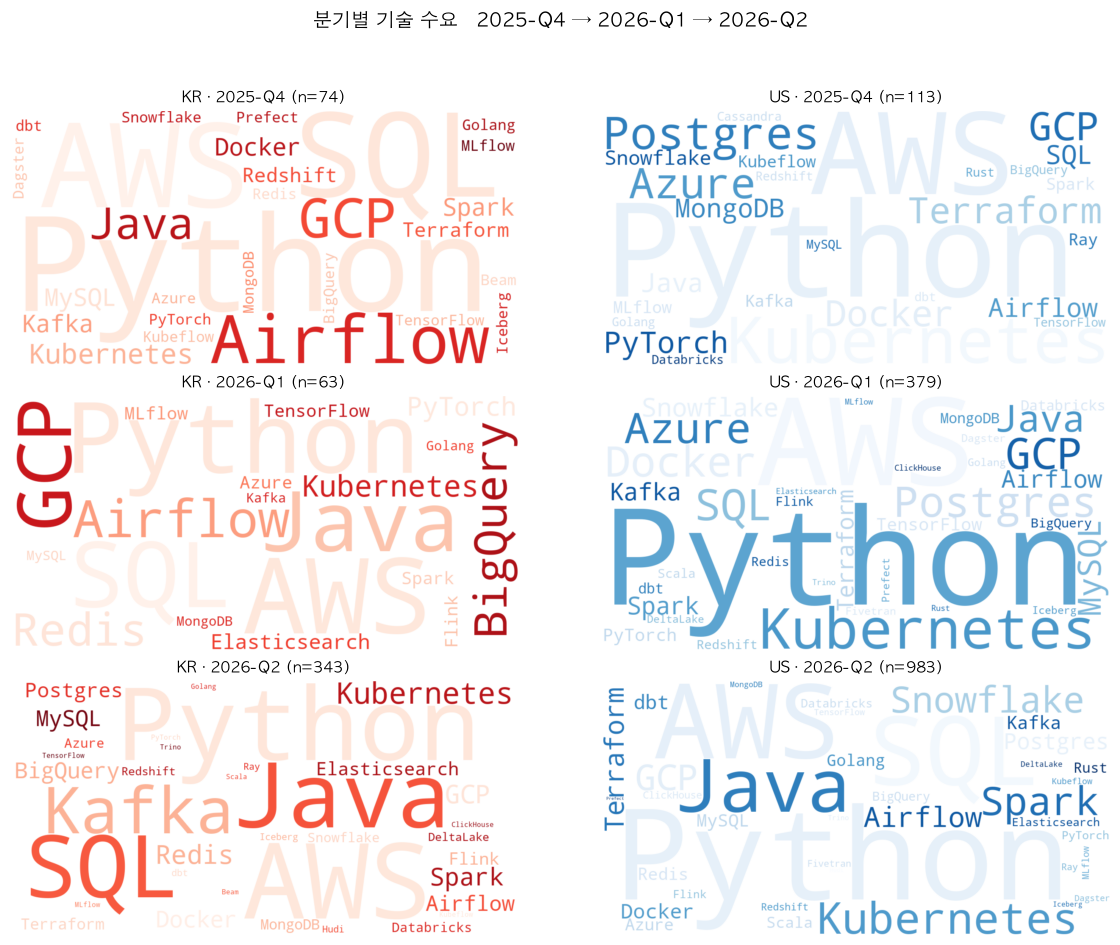

In [23]:
m = load_mentions()
fig, _ = view_quarterly(m)

### 커스텀 가중치

1. 회사 1회 집계
2. 전체 분기 대비 해당 분기에 많이 언급된 것을 더 크게 표현

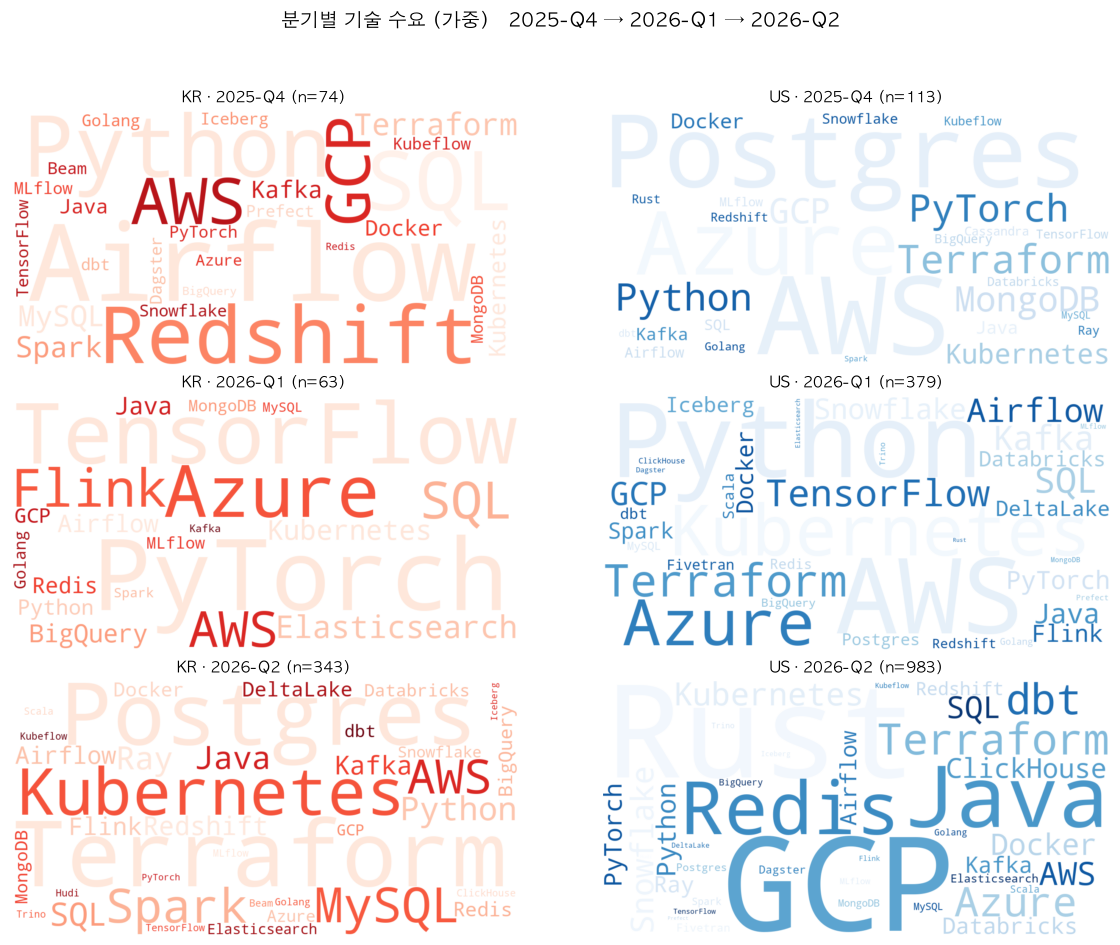

In [24]:
m = load_mentions()
fig, _ = view_quarterly(m, weighted=True)

---
# 직무별 기술 스택

### 가중치 없음

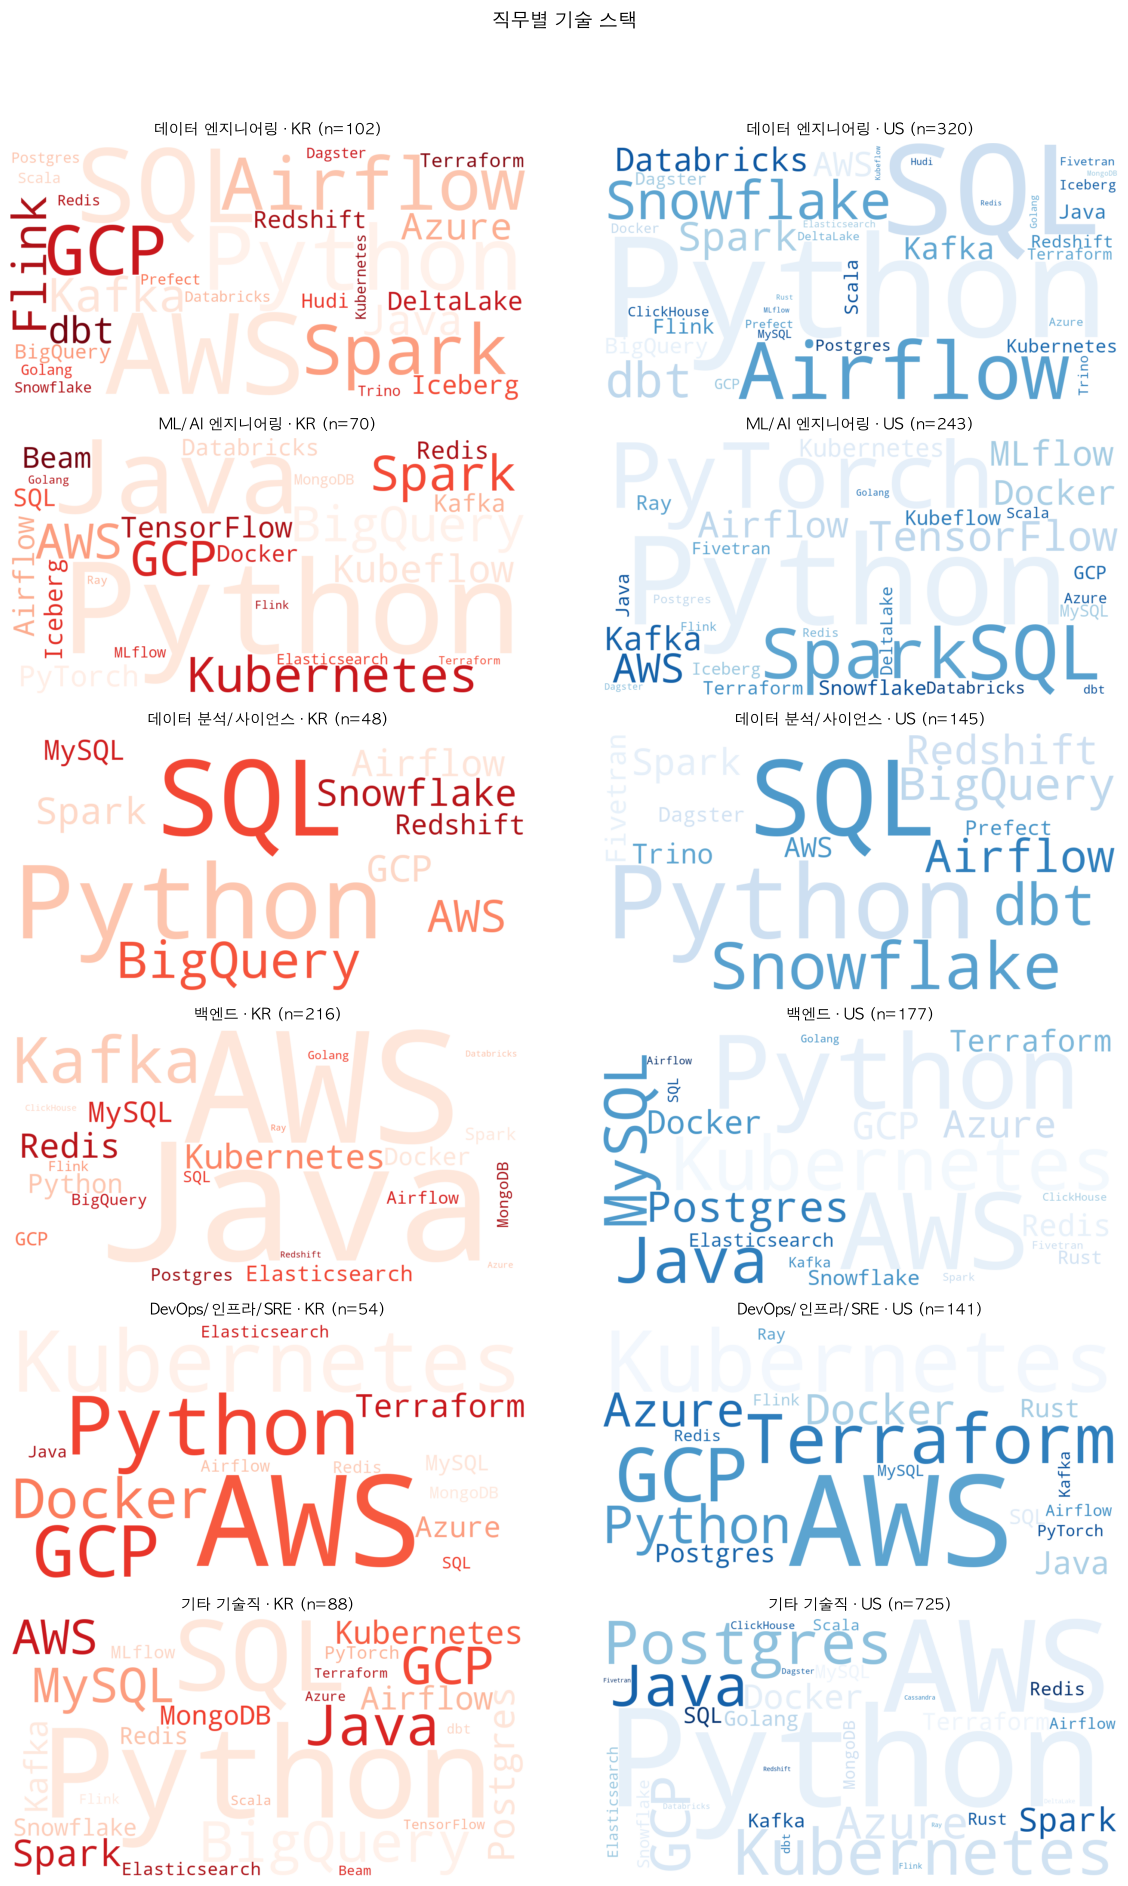

In [25]:
m = load_mentions()
fig, _ = view_by_category(m)

### 커스텀 가중치 3개

1. 오래된 정보에 가중치 * 0.6
2. 회사별로 1개 집계
3. 전체 기술 내용에서 해당 직무에서 많이 언급되는 것에 가중치

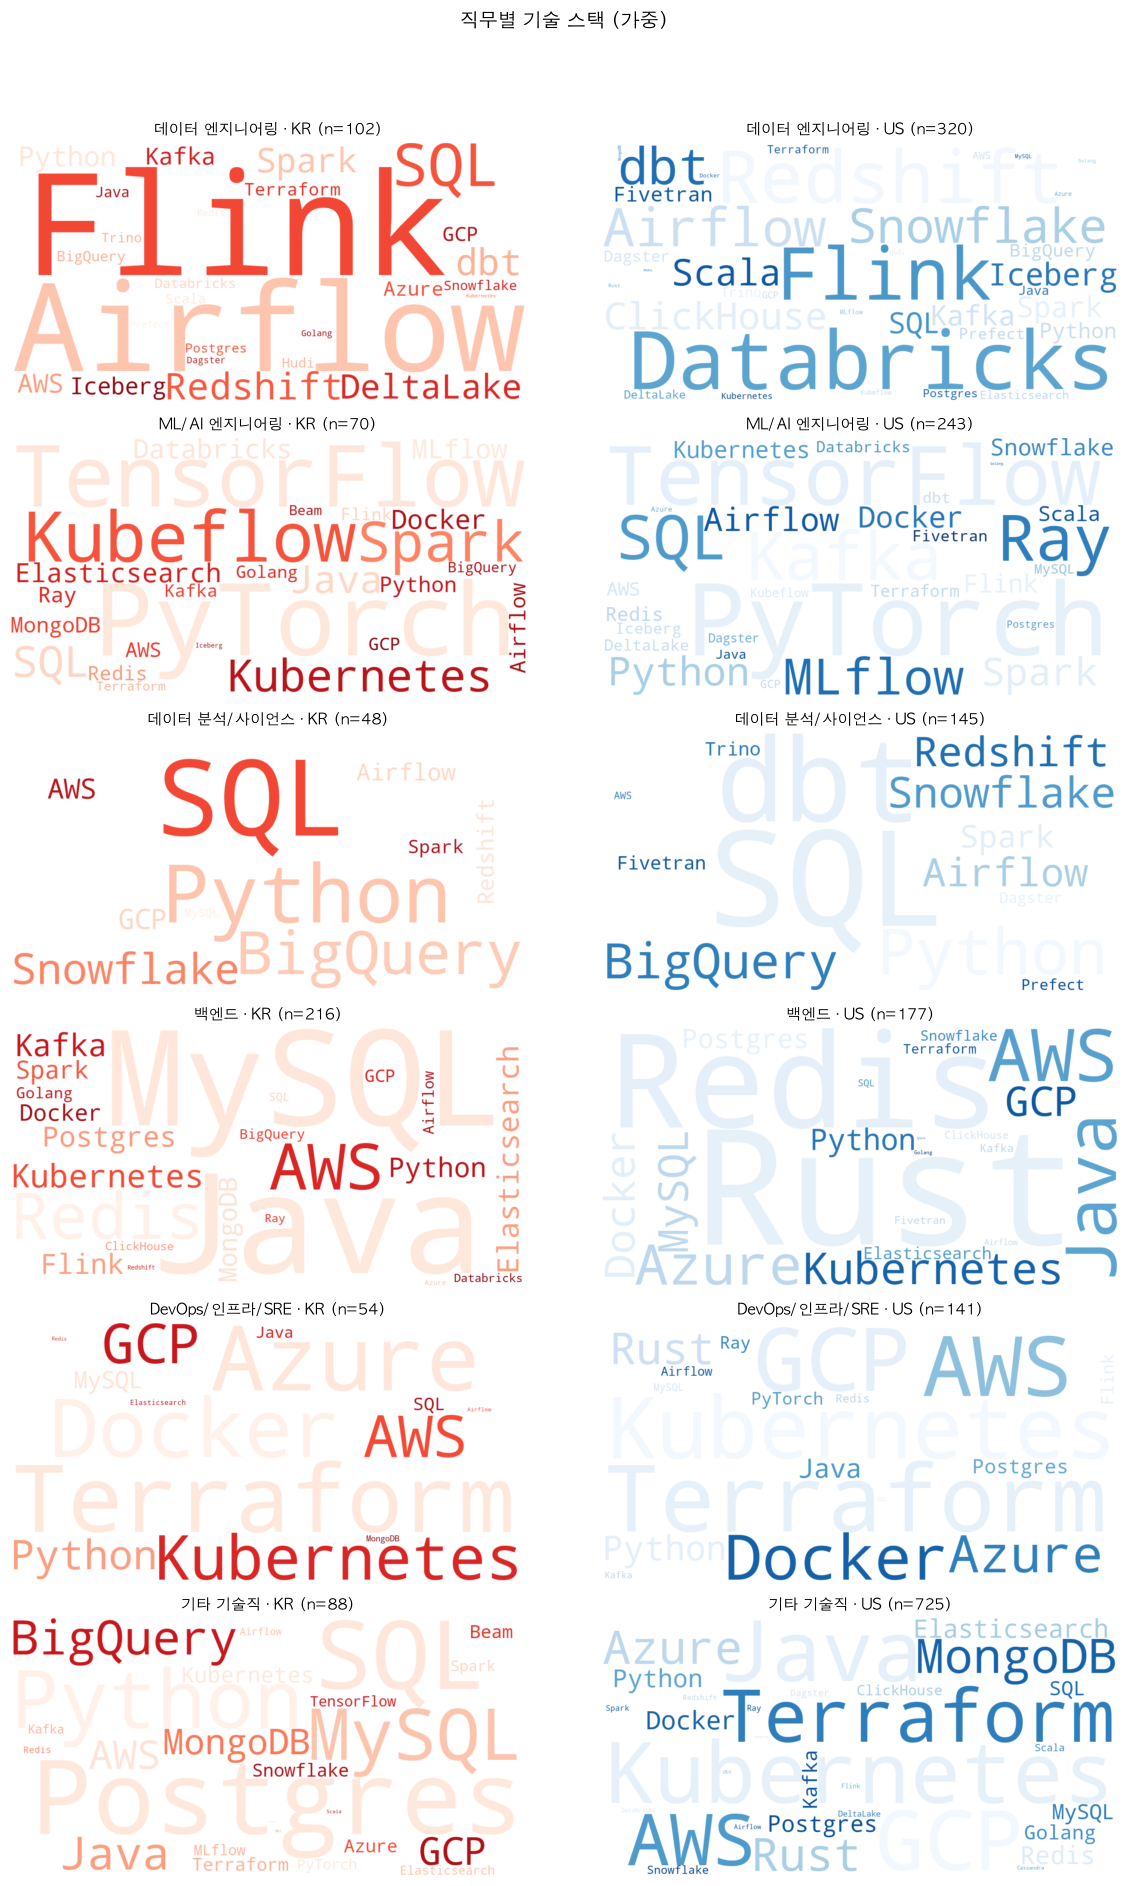

In [26]:
m = load_mentions()
fig, _ = view_by_category(m, weighted=True)

---
# 초기 프로토타입 
> DE 기술 점유율 확인

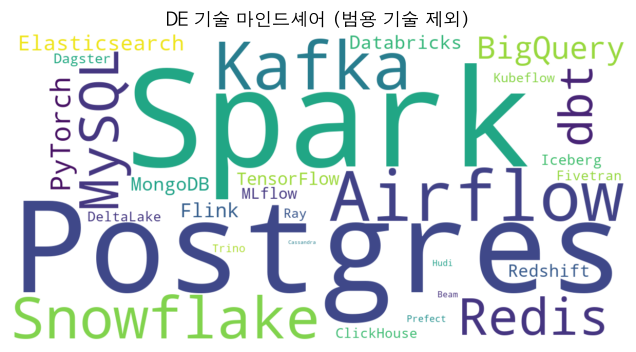

In [27]:
m = load_mentions()
fig, _ = view_mindshare(m)

## US vs KR 비교 (범용 기술 제외)

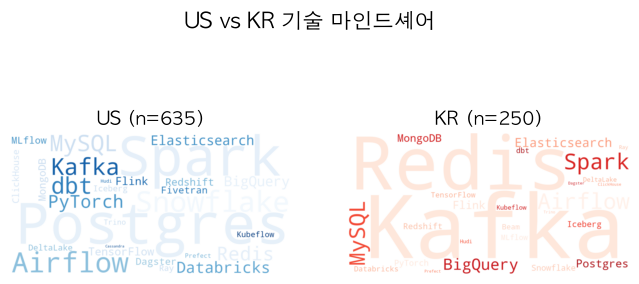

In [28]:
m = load_mentions()
fig, _ = view_us_vs_kr(m)

## 모멘텀 (빨강=상승 / 파랑=하락)

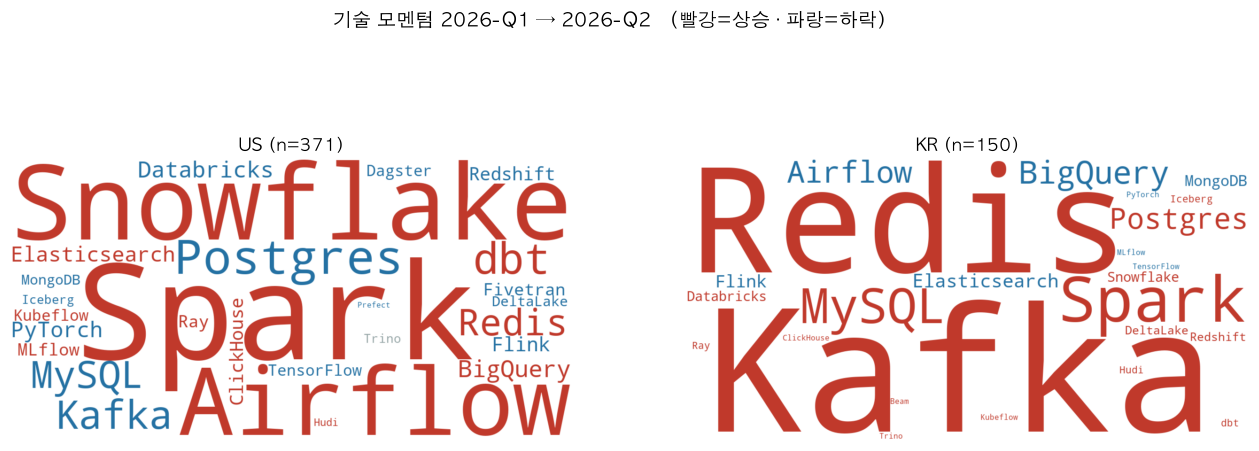

In [29]:
m = load_mentions()
qe, ql = pick_momentum_quarters(m)
fig, _ = view_momentum(m, qe, ql)

## 데이터 웨어하우스 점유율 확인

country,KR,US
tech,,
Snowflake,8.4,36.5
Databricks,6.7,10.3
BigQuery,35.4,9.7
Redshift,8.4,7.4
Synapse,0.0,0.0


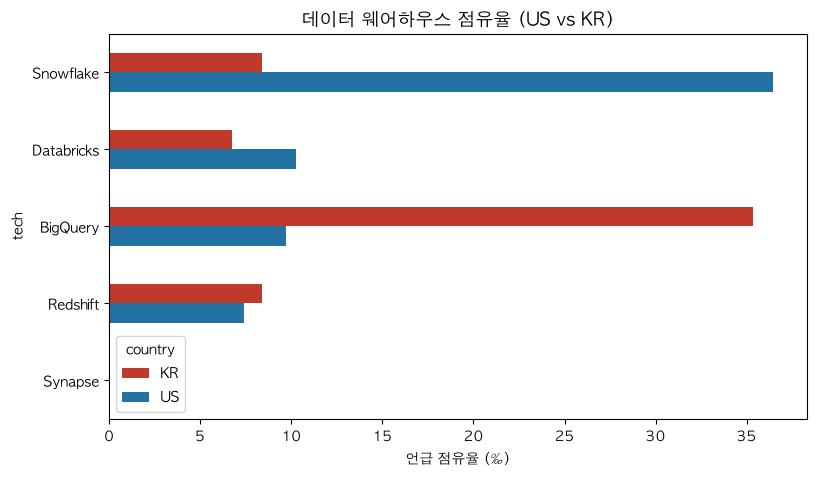

In [30]:
m = load_mentions()
fig, df = view_competitor_bar(m)
display(df.round(1))

## 세부 제품 점유율

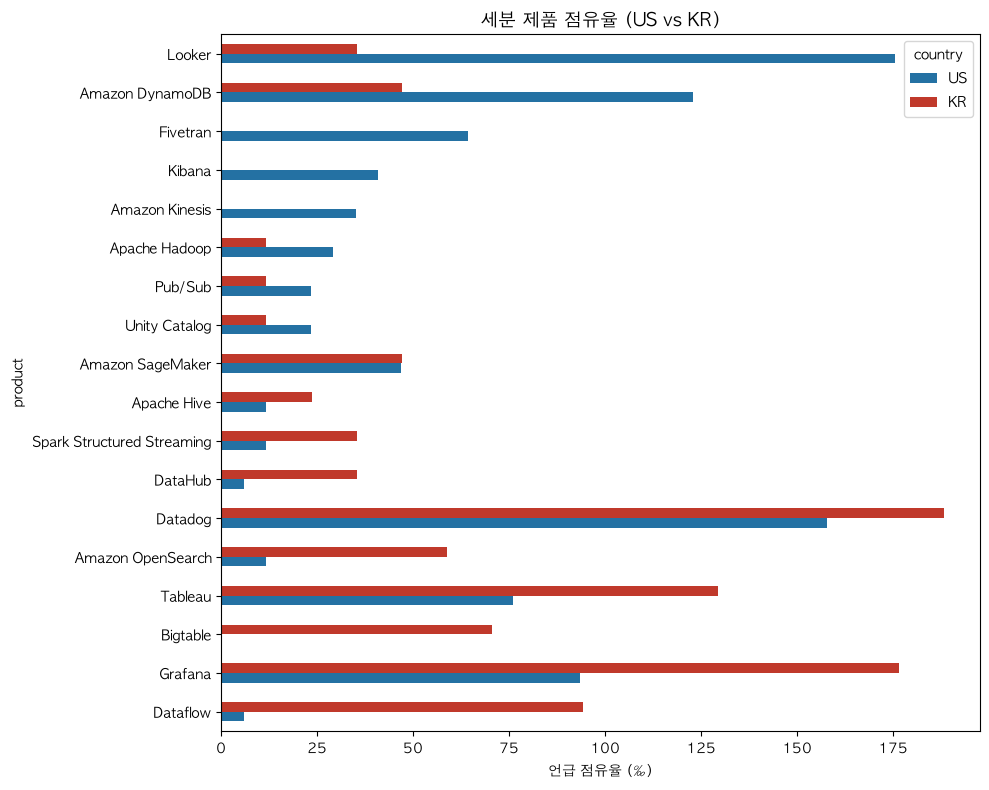

In [31]:
g = load_granular()
fig, _ = view_granular_bar(g)